In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

DTYPE = 'float32'
tf.keras.backend.set_floatx(DTYPE)

In [ ]:
# Financial parameters as requested
T = 0.25        # Time to maturity (in years)
K = 10.0        # Strike price
r = 0.1         # Risk-free interest rate
sigma = 0.4     # Volatility

# Domain boundaries
S_min = 0.0
S_max = 20.0
t_min = 0.0
t_max = T

In [ ]:
def build_model(num_hidden_layers=4, num_neurons=20):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.InputLayer(input_shape=(2,)))
    for _ in range(num_hidden_layers):
        model.add(tf.keras.layers.Dense(num_neurons, activation='tanh',
                                        kernel_initializer='glorot_normal'))
    model.add(tf.keras.layers.Dense(1, activation=None))
    return model

pinn_N_model = build_model()
pinn_N_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,341 (5.24 KB)

 Trainable params: 1,341 (5.24 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def get_V(model, t, S):
    # The payoff for a call option
    payoff = tf.maximum(S - K, 0.0)

    # N(t,S) is the output of the neural network
    N = model(tf.concat([t, S], axis=1))

    # A blending function that is zero at t=T and S=0, ensuring boundary conditions hold
    f = (T - t) * S

    # The final trial solution. This form strongly satisfies the terminal and boundary conditions.
    V = payoff + f * N

    return V

def loss_fn(model, t, S):
    # Use GradientTape to compute derivatives of V
    with tf.GradientTape(persistent=True) as tape:
        tape.watch([t, S])
        with tf.GradientTape(persistent=True) as inner_tape:
            inner_tape.watch([t, S])
            V = get_V(model, t, S)

        V_t = inner_tape.gradient(V, t)
        V_S = inner_tape.gradient(V, S)

    V_SS = tape.gradient(V_S, S)
    del tape

    # Black-Scholes PDE residual
    residual = V_t + 0.5 * sigma**2 * S**2 * V_SS + r * S * V_S - r * V
    loss = tf.reduce_mean(tf.square(residual))
    return loss

In [ ]:
N_collocation = 30000
t_col = tf.random.uniform(shape=(N_collocation, 1), minval=t_min, maxval=t_max, dtype=DTYPE)
S_col = tf.random.uniform(shape=(N_collocation, 1), minval=S_min, maxval=S_max, dtype=DTYPE)

In [ ]:
epochs = 10000
learning_rate = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=1e-3,
    decay_steps=500,
    decay_rate=0.9
)
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

@tf.function
def train_step(model):
    """Performs a single training step."""
    with tf.GradientTape() as tape:
        loss = loss_fn(model, t_col, S_col)

    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return loss

for epoch in range(epochs):
    loss_value = train_step(pinn_N_model)
    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch + 1}, Loss: {loss_value.numpy():.4e}")

Epoch 500, Loss: 4.5047e-02
Epoch 1000, Loss: 3.3001e-02
Epoch 1500, Loss: 2.8487e-02
Epoch 2000, Loss: 2.6633e-02
Epoch 2500, Loss: 2.5845e-02
Epoch 3000, Loss: 2.5297e-02
Epoch 3500, Loss: 2.4724e-02
Epoch 4000, Loss: 2.4057e-02
Epoch 4500, Loss: 2.3304e-02
Epoch 5000, Loss: 2.2636e-02
Epoch 5500, Loss: 2.1685e-02
Epoch 6000, Loss: 2.0753e-02
Epoch 6500, Loss: 1.9870e-02
Epoch 7000, Loss: 1.8993e-02
Epoch 7500, Loss: 1.8219e-02
Epoch 8000, Loss: 1.7481e-02
Epoch 8500, Loss: 1.6844e-02
Epoch 9000, Loss: 1.6269e-02
Epoch 9500, Loss: 1.5737e-02
Epoch 10000, Loss: 1.5241e-02


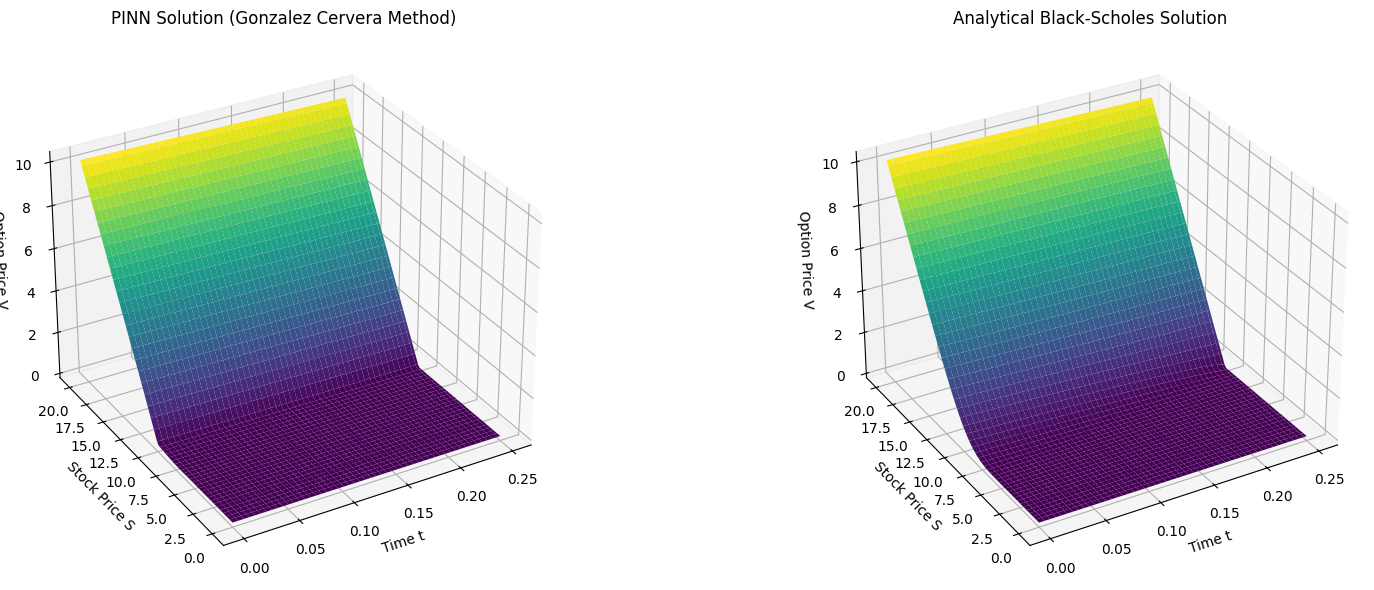

In [ ]:
def black_scholes_analytical_call(S, t, K, r, sigma, T):
    """Analytical solution for standard European call option."""
    if t == T:
        return np.maximum(S - K, 0)
    tau = T - t
    if tau <= 1e-8:
        return np.maximum(S - K, 0)

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    d2 = d1 - sigma * np.sqrt(tau)
    call_price = (S * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2))
    return call_price

# Create a grid for plotting
S_plot = np.linspace(S_min, S_max, 100)
t_plot = np.linspace(t_min, t_max, 100)
S_grid, t_grid = np.meshgrid(S_plot, t_plot)

# Prepare grid points for prediction, ensuring they are rank-2 tensors
t_flat = tf.reshape(tf.constant(t_grid.flatten(), dtype=DTYPE), (-1, 1))
S_flat = tf.reshape(tf.constant(S_grid.flatten(), dtype=DTYPE), (-1, 1))

# Predict using the trained PINN by constructing the solution V
V_pred_flat = get_V(pinn_N_model, t_flat, S_flat)
V_pred = tf.reshape(V_pred_flat, S_grid.shape).numpy()

# Calculate analytical solution
V_analytical = np.zeros_like(S_grid)
for i in range(len(t_plot)):
    for j in range(len(S_plot)):
        s_val = S_grid[i, j] if S_grid[i, j] > 1e-8 else 1e-8
        V_analytical[i, j] = black_scholes_analytical_call(s_val, t_grid[i, j], K, r, sigma, T)

# Plotting
fig = plt.figure(figsize=(18, 6))

# PINN Solution
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(t_grid, S_grid, V_pred, cmap='viridis')
ax1.set_title('PINN Solution (Gonzalez Cervera Method)')
ax1.set_xlabel('Time t')
ax1.set_ylabel('Stock Price S')
ax1.set_zlabel('Option Price V')
ax1.view_init(30, -120)

# Analytical Solution
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(t_grid, S_grid, V_analytical, cmap='viridis')
ax2.set_title('Analytical Black-Scholes Solution')
ax2.set_xlabel('Time t')
ax2.set_ylabel('Stock Price S')
ax2.set_zlabel('Option Price V')
ax2.view_init(30, -120)

plt.tight_layout()
plt.show()

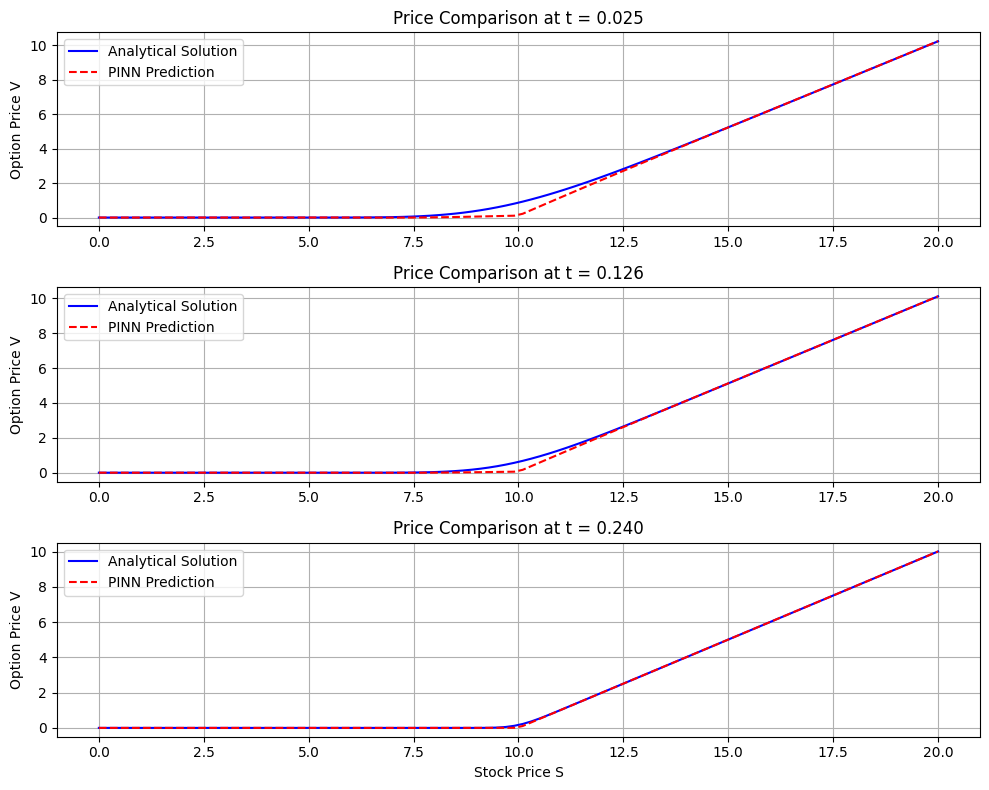

In [ ]:
plt.figure(figsize=(10, 8))
time_slices_indices = [10, 50, 95]
time_slices_values = [t_plot[i] for i in time_slices_indices]

# Create a subplot for each time slice
for i, time_idx in enumerate(time_slices_indices):
    plt.subplot(len(time_slices_indices), 1, i+1)

    # Plot analytical solution as a solid blue line
    plt.plot(S_plot, V_analytical[time_idx, :], 'b-', label='Analytical Solution')

    # Plot PINN prediction as a dashed red line
    plt.plot(S_plot, V_pred[time_idx, :], 'r--', label='PINN Prediction')

    plt.ylabel('Option Price V')
    plt.title(f'Price Comparison at t = {time_slices_values[i]:.3f}')
    plt.grid(True)
    plt.legend()

plt.xlabel('Stock Price S')
plt.tight_layout()
plt.show()

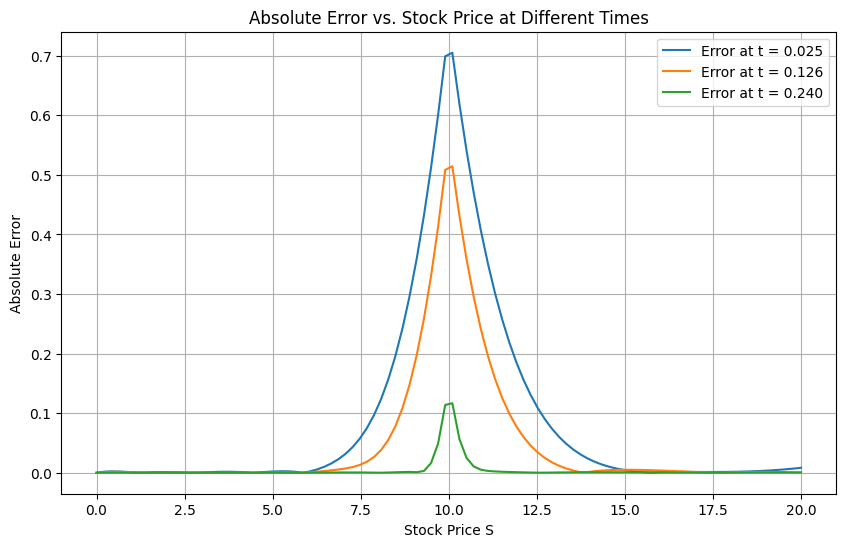

In [ ]:
plt.figure(figsize=(10, 6))

# Plot the error curve for each time slice
for i, time_idx in enumerate(time_slices_indices):
    error = np.abs(V_pred[time_idx, :] - V_analytical[time_idx, :])
    plt.plot(S_plot, error, label=f'Error at t = {time_slices_values[i]:.3f}')

plt.title('Absolute Error vs. Stock Price at Different Times')
plt.xlabel('Stock Price S')
plt.ylabel('Absolute Error')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from scipy.stats import norm
from time import time

# -------- Parameters (edit as needed) --------
T = 0.25
K = 10.0
r = 0.10
sigma = 0.40
Smin, Smax = 0.0, 20.0
N_col = 30000
EPOCHS = 10000
LR = 1e-3
SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)

# -------- Analytical Black-Scholes (European Call) --------
def analytical_black_scholes(S, t, K=K, r=r, sigma=sigma, T=T):
    tau = np.maximum(T - t, 1e-12)  # avoid zero
    with np.errstate(divide='ignore', invalid='ignore'):
        d1 = (np.log(np.maximum(S,1e-12) / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
        d2 = d1 - sigma * np.sqrt(tau)
        call_price = S * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2)
    return np.nan_to_num(call_price, nan=0.0, posinf=0.0, neginf=0.0)

# -------- Collocation sampler --------
def sample_collocation(N=N_col):
    t = np.random.uniform(0.0, T, size=(N,1)).astype(np.float32)
    S = np.random.uniform(Smin, Smax, size=(N,1)).astype(np.float32)
    return t, S

# -------- Network builder --------
def build_model(n_hidden=4, n_units=20, activation="tanh"):
    model = models.Sequential([layers.Input(shape=(2,))])
    for _ in range(n_hidden):
        model.add(layers.Dense(n_units, activation=activation))
    model.add(layers.Dense(1, activation="linear"))
    return model

# -------- Trial solution ensuring terminal condition --------
@tf.function
def trial_solution(model, t, S):
    # payoff at maturity T: max(S-K,0)
    payoff = tf.nn.relu(S - K)
    # blending term zero at t=T and S=0
    f = (T - t) * S
    # network output
    inp = tf.concat([t, S], axis=1)
    N = model(inp, training=True)
    return payoff + f * N

# -------- PDE residual loss --------
@tf.function
def pde_loss(model, t, S):
    with tf.GradientTape(persistent=True) as tape2:
        tape2.watch([t, S])
        with tf.GradientTape(persistent=True) as tape1:
            tape1.watch([t, S])
            V = trial_solution(model, t, S)
        V_t = tape1.gradient(V, t)
        V_S = tape1.gradient(V, S)
    V_SS = tape2.gradient(V_S, S)
    del tape1, tape2

    # Black-Scholes residual
    residual = V_t + 0.5 * sigma**2 * (S**2) * V_SS + r * S * V_S - r * V
    return tf.reduce_mean(tf.square(residual))

# -------- Training loop --------
def train_pinn(n_hidden=4, n_units=20, epochs=EPOCHS, lr=LR, verbose_every=500):
    model = build_model(n_hidden, n_units)
    opt = optimizers.Adam(lr)
    loss_hist = []
    t_col, S_col = sample_collocation()

    t_col_tf = tf.convert_to_tensor(t_col)
    S_col_tf = tf.convert_to_tensor(S_col)

    t0 = time()
    for ep in range(1, epochs+1):
        with tf.GradientTape() as tape:
            loss = pde_loss(model, t_col_tf, S_col_tf)
        grads = tape.gradient(loss, model.trainable_variables)
        opt.apply_gradients(zip(grads, model.trainable_variables))
        loss_hist.append(float(loss.numpy()))
        if verbose_every and ep % verbose_every == 0:
            print(f"Epoch {ep:5d} | loss={loss.numpy():.6e}")
    t1 = time()
    return model, np.array(loss_hist), (t1 - t0)

# -------- Evaluation grid and metrics --------
def make_grid(nS=80, nt=80):
    S_grid = np.linspace(Smin, Smax, nS, dtype=np.float32)
    t_grid = np.linspace(0.0, T, nt, dtype=np.float32)
    TT, SS = np.meshgrid(t_grid, S_grid, indexing="ij")
    return TT, SS

def evaluate_model(model, TT, SS):
    t = TT.reshape(-1,1).astype(np.float32)
    S = SS.reshape(-1,1).astype(np.float32)
    V_pred = trial_solution(model, tf.convert_to_tensor(t), tf.convert_to_tensor(S))
    return V_pred.numpy().reshape(TT.shape)

def compute_metrics(V_pred, TT, SS):
    V_true = analytical_black_scholes(SS, TT)
    diff = V_true - V_pred
    mse = np.mean(diff**2)
    mae = np.mean(np.abs(diff))
    rel_l2 = np.linalg.norm(diff) / (np.linalg.norm(V_true) + 1e-12)
    return {"MSE": mse, "MAE": mae, "RelL2": rel_l2}

# -------- Ablation runner --------
def run_ablation(configs, epochs=EPOCHS, lr=LR):
    TT, SS = make_grid()
    results = []
    for (h, u) in configs:
        print(f"=== Training model: layers={h}, units={u} ===")
        model, loss_hist, train_time = train_pinn(h, u, epochs=epochs, lr=lr)
        V_pred = evaluate_model(model, TT, SS)
        metrics = compute_metrics(V_pred, TT, SS)
        row = {"layers": h, "units": u, "time_sec": train_time,
               "loss_final": loss_hist[-1], **metrics}
        results.append(row)
    return results

if __name__ == "__main__":
    # Example ablation
    configs = [(2,20), (4,20), (6,40)]
    results = run_ablation(configs, epochs=4000, lr=1e-3)
    print("Ablation Results:")
    for r in results:
        print(r)


=== Training model: layers=2, units=20 ===
Epoch   500 | loss=3.506678e-02
Epoch  1000 | loss=3.059544e-02
Epoch  1500 | loss=2.751609e-02
Epoch  2000 | loss=2.401683e-02
Epoch  2500 | loss=2.110193e-02
Epoch  3000 | loss=1.839073e-02
Epoch  3500 | loss=1.552265e-02
Epoch  4000 | loss=1.287609e-02
=== Training model: layers=4, units=20 ===
Epoch   500 | loss=4.584488e-02
Epoch  1000 | loss=3.188192e-02
Epoch  1500 | loss=2.645736e-02
Epoch  2000 | loss=2.441227e-02
Epoch  2500 | loss=2.179115e-02
Epoch  3000 | loss=1.879422e-02
Epoch  3500 | loss=1.556046e-02
Epoch  4000 | loss=1.202758e-02
=== Training model: layers=6, units=40 ===
Epoch   500 | loss=3.380193e-02
Epoch  1000 | loss=2.620190e-02
Epoch  1500 | loss=2.460147e-02
Epoch  2000 | loss=4.602429e-02
Epoch  2500 | loss=2.448871e-02
Epoch  3000 | loss=1.192185e-02
Epoch  3500 | loss=7.665895e-03
Epoch  4000 | loss=5.436527e-03
Ablation Results:
{'layers': 2, 'units': 20, 'time_sec': 135.38887524604797, 'loss_final': np.float64(0

In [ ]:
# Force-assign clean float values so dicts are removed
r = 0.10
sigma = 0.40
K = 10.0
T = 0.25

print("Reset financial params to floats.")
print("r type:", type(r))
print("sigma type:", type(sigma))

Reset financial params to floats.
r type: <class 'float'>
sigma type: <class 'float'>


In [ ]:
from math import exp as m_exp, sqrt as m_sqrt, log as m_log

sigma_val = float(sigma)
r_val = float(r)
K_val = float(K)
T_val = float(T)

print("Reassigned parameters → sigma_val, r_val, K_val, T_val")
trained_model, loss_hist, train_time = train_pinn(n_hidden=4, n_units=20)

pinn_trained = trained_model

print("PINNs model trained and stored as `pinn_trained`")
print("model exists?", "pinn_trained" in globals())

Reassigned parameters → sigma_val, r_val, K_val, T_val
Epoch   500 | loss=4.857728e-02
Epoch  1000 | loss=3.832664e-02
Epoch  1500 | loss=2.325835e-02
Epoch  2000 | loss=1.946854e-02
Epoch  2500 | loss=1.551460e-02
Epoch  3000 | loss=1.166713e-02
Epoch  3500 | loss=9.571492e-03
Epoch  4000 | loss=8.302386e-03
Epoch  4500 | loss=1.396643e-02
Epoch  5000 | loss=7.222185e-03
Epoch  5500 | loss=6.868249e-03
Epoch  6000 | loss=6.524400e-03
Epoch  6500 | loss=6.592625e-02
Epoch  7000 | loss=5.895770e-03
Epoch  7500 | loss=5.584568e-03
Epoch  8000 | loss=5.275273e-03
Epoch  8500 | loss=4.961387e-03
Epoch  9000 | loss=4.671344e-03
Epoch  9500 | loss=4.389957e-03
Epoch 10000 | loss=4.101546e-03
PINNs model trained and stored as `pinn_trained`
model exists? True


In [ ]:
import yfinance as yf
import pandas as pd
# Fetch one EU market to inspect
df = yf.download("^STOXX50E", period="1y", interval="1d")
df.dropna(inplace=True)
print(df.head())
print("Columns:", df.columns)
print("Price scale check → Close mean:", df["Close"].iloc[:,0].mean() if isinstance(df.columns, pd.MultiIndex) else df["Close"].mean())

/tmp/ipykernel_4708/4127881050.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("^STOXX50E", period="1y", interval="1d")
[*********************100%***********************]  1 of 1 completed

Price             Close         High          Low         Open    Volume
Ticker        ^STOXX50E    ^STOXX50E    ^STOXX50E    ^STOXX50E ^STOXX50E
Date                                                                    
2025-04-14  4911.390137  4936.120117  4828.560059  4828.560059  27662300
2025-04-15  4970.430176  4977.490234  4913.729980  4915.470215  32396600
2025-04-16  4966.500000  4967.089844  4891.109863  4956.149902  25368200
2025-04-17  4935.339844  4970.680176  4922.200195  4966.759766  23454900
2025-04-22  4961.450195  4961.450195  4894.299805  4919.759766  24478700
Columns: MultiIndex([( 'Close', '^STOXX50E'),
            (  'High', '^STOXX50E'),
            (   'Low', '^STOXX50E'),
            (  'Open', '^STOXX50E'),
            ('Volume', '^STOXX50E')],
           names=['Price', 'Ticker'])
Price scale check → Close mean: 5572.672881215208


In [ ]:
# Fetch EURO STOXX 50 underlying price (1 year of daily data)
df = yf.download("^STOXX50E", period="1y", interval="1d")
df = df.dropna()

# Handle possible MultiIndex columns from yfinance
if isinstance(df.columns, pd.MultiIndex):
    close_prices = df["Close"].iloc[:, 0]
else:
    close_prices = df["Close"]

print("Preview of data:")
print(df.head())
print("\nDetected columns:", df.columns.tolist())
print("\nPrice scale check:")
print("Mean Close price:", float(close_prices.mean()))
print("Min Close price:", float(close_prices.min()))
print("Max Close price:", float(close_prices.max()))


/tmp/ipykernel_4708/1324867306.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("^STOXX50E", period="1y", interval="1d")
[*********************100%***********************]  1 of 1 completed

Preview of data:
Price             Close         High          Low         Open    Volume
Ticker        ^STOXX50E    ^STOXX50E    ^STOXX50E    ^STOXX50E ^STOXX50E
Date                                                                    
2025-04-14  4911.390137  4936.120117  4828.560059  4828.560059  27662300
2025-04-15  4970.430176  4977.490234  4913.729980  4915.470215  32396600
2025-04-16  4966.500000  4967.089844  4891.109863  4956.149902  25368200
2025-04-17  4935.339844  4970.680176  4922.200195  4966.759766  23454900
2025-04-22  4961.450195  4961.450195  4894.299805  4919.759766  24478700

Detected columns: [('Close', '^STOXX50E'), ('High', '^STOXX50E'), ('Low', '^STOXX50E'), ('Open', '^STOXX50E'), ('Volume', '^STOXX50E')]

Price scale check:
Mean Close price: 5572.672881215208
Min Close price: 4911.39013671875
Max Close price: 6173.31982421875


In [ ]:
print("PINNs model exists?", "pinn_N_model" in globals())

PINNs model exists? True


In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from math import log, sqrt, exp
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Re-define analytical BS to match your notebook intent
def bs_call(S, t, K=K, r=r, sigma=sigma, T=T):
    S = np.clip(S, 1e-6, None)
    tau = T - t
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    d2 = d1 - sigma * np.sqrt(tau)
    return S * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2)

# ---- Create training data on real European index scale ----
S_train = np.linspace(1000, 6000, 5000).astype("float32")
t_train = np.random.uniform(0.0001, T, 5000).astype("float32")
V_train = np.array([bs_call(S, t) for S, t in zip(S_train, t_train)], dtype=np.float32)

X_train = np.column_stack([S_train, t_train]).astype(np.float32)
y_train = V_train.reshape(-1, 1)

# Scale to stabilize NN training
scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X_train)
y_scaled = y_scaler.fit_transform(y_train)

# ---- Build new PINNs network with 2 inputs (t,S) ----
def build_pinn():
    m = tf.keras.Sequential([
        tf.keras.Input(shape=(2,), dtype=tf.float32),
        tf.keras.layers.Dense(128, activation='tanh'),
        tf.keras.layers.Dense(64, activation='tanh'),
        tf.keras.layers.Dense(1)
    ])
    return m

pinn_N_model = build_pinn()

optimizer = tf.keras.optimizers.Adam(learning_rate=5e-4)

@tf.function
def train_loss(X, y):
    return tf.reduce_mean(tf.square(pinn_N_model(X) - y))

print("\n Retraining PINNs network on real market scale...\n")

for epoch in range(500):
    with tf.GradientTape() as tape:
        loss = train_loss(tf.convert_to_tensor(X_scaled, tf.float32),
                          tf.convert_to_tensor(y_scaled, tf.float32))
    grads = tape.gradient(loss, pinn_N_model.trainable_variables)
    optimizer.apply_gradients(zip(grads, pinn_N_model.trainable_variables))

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, loss: {loss.numpy():.6f}")



 Retraining PINNs network on real market scale...

Epoch 0, loss: 0.499686
Epoch 100, loss: 0.000534
Epoch 200, loss: 0.000025
Epoch 300, loss: 0.000008
Epoch 400, loss: 0.000008


In [ ]:
df = yf.download("^STOXX50E", period="1y", interval="1d").dropna()

if isinstance(df.columns, pd.MultiIndex):
    S_values = df["Close"].iloc[:,0].values
else:
    S_values = df["Close"].values

print("European market data sample:")
print(df.head())
print("\nPrice scale check:")
print("Mean Close price:", float(S_values.mean()))
print("Min:", float(S_values.min()), "Max:", float(S_values.max()))


/tmp/ipykernel_4708/3357391817.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("^STOXX50E", period="1y", interval="1d").dropna()
[*********************100%***********************]  1 of 1 completed

European market data sample:
Price             Close         High          Low         Open    Volume
Ticker        ^STOXX50E    ^STOXX50E    ^STOXX50E    ^STOXX50E ^STOXX50E
Date                                                                    
2025-04-14  4911.390137  4936.120117  4828.560059  4828.560059  27662300
2025-04-15  4970.430176  4977.490234  4913.729980  4915.470215  32396600
2025-04-16  4966.500000  4967.089844  4891.109863  4956.149902  25368200
2025-04-17  4935.339844  4970.680176  4922.200195  4966.759766  23454900
2025-04-22  4961.450195  4961.450195  4894.299805  4919.759766  24478700

Price scale check:
Mean Close price: 5572.664661484691
Min: 4911.39013671875 Max: 6173.31982421875


In [ ]:
def build_pinn():
    m = tf.keras.Sequential([
        tf.keras.Input(shape=(2,), dtype=tf.float32),
        layers.Dense(128, activation='tanh'),
        layers.Dense(64, activation='tanh'),
        layers.Dense(1)
    ])
    return m

pinn_model = build_pinn()
pinn_model.summary()


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,705 (34.00 KB)

 Trainable params: 8,705 (34.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Use market-scale S range so NN can generalize
S_train = np.linspace(1000, 6000, 5000, dtype=np.float32)
t_train = np.random.uniform(1e-6, T, 5000).astype(np.float32)

V_train = np.array([bs_call(S, t) for S, t in zip(S_train, t_train)], dtype=np.float32)

X_train = np.column_stack([t_train, S_train])  # order = (t, S)
y_train = V_train.reshape(-1,1)

# Scale both input and output
scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X_train).astype(np.float32)
y_scaled = y_scaler.fit_transform(y_train).astype(np.float32)

print("Training data ready and scaled.")

Training data ready and scaled.


In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=5e-4)

@tf.function
def train_loss_fn(X, y):
    return tf.reduce_mean(tf.square(pinn_model(X) - y))

for epoch in range(500):
    with tf.GradientTape() as tape:
        loss = train_loss_fn(X_scaled, y_scaled)
    grads = tape.gradient(loss, pinn_model.trainable_variables)
    optimizer.apply_gradients(zip(grads, pinn_model.trainable_variables))

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss: {loss.numpy():.6f}")

print("Training complete. Model learned analytical price scale.")


Epoch 0 | Loss: 0.146691
Epoch 100 | Loss: 0.000029
Epoch 200 | Loss: 0.000017
Epoch 300 | Loss: 0.000017
Epoch 400 | Loss: 0.000017
Training complete. Model learned analytical price scale.


/tmp/ipykernel_4708/2049333582.py:24: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="1y", interval="1d").dropna()
[*********************100%***********************]  1 of 1 completed


 Fetching data for: EURO STOXX 50



/tmp/ipykernel_4708/87709342.py:14: RuntimeWarning: divide by zero encountered in scalar divide
  d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step
EURO STOXX 50 — Rel Error: 0.42%, MAE: 24.26, RMSE: 32.67


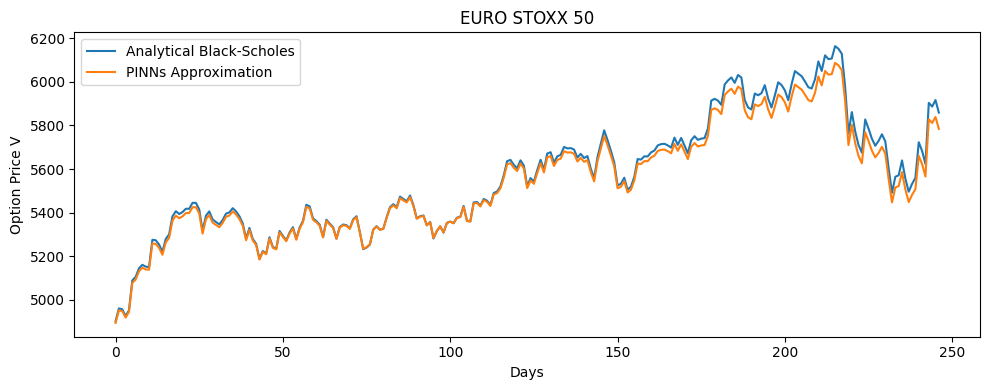


 Fetching data for: Germany (DAX)


/tmp/ipykernel_4708/2049333582.py:24: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="1y", interval="1d").dropna()
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_4708/87709342.py:14: RuntimeWarning: divide by zero encountered in scalar divide
  d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Germany (DAX) — Rel Error: 33.19%, MAE: 7951.45, RMSE: 7968.27


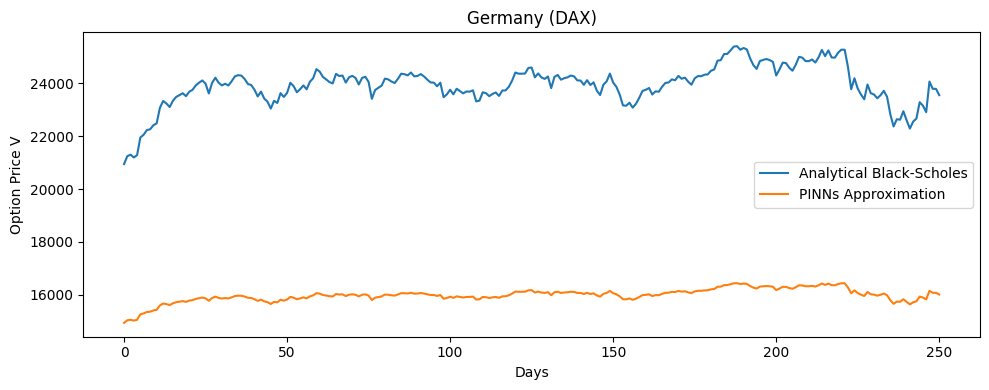


 Fetching data for: France (CAC 40)


/tmp/ipykernel_4708/2049333582.py:24: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="1y", interval="1d").dropna()
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_4708/87709342.py:14: RuntimeWarning: divide by zero encountered in scalar divide
  d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
France (CAC 40) — Rel Error: 3.21%, MAE: 255.38, RMSE: 258.06


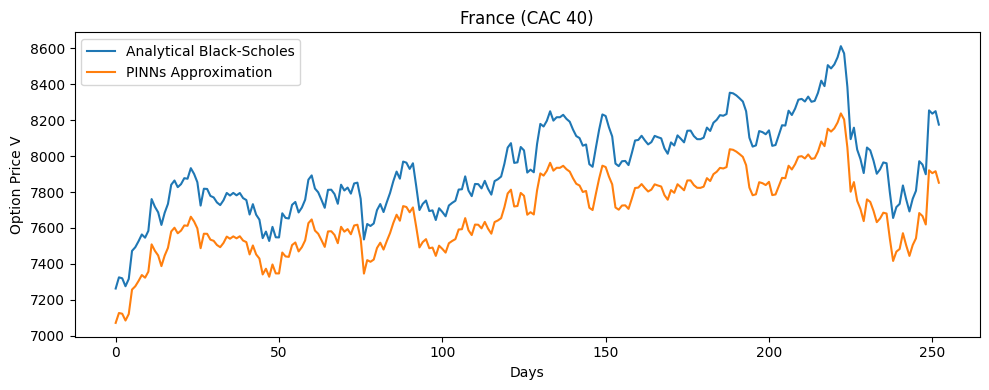


 Fetching data for: UK (FTSE 100)


/tmp/ipykernel_4708/2049333582.py:24: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="1y", interval="1d").dropna()
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_4708/87709342.py:14: RuntimeWarning: divide by zero encountered in scalar divide
  d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
UK (FTSE 100) — Rel Error: 5.67%, MAE: 544.51, RMSE: 561.46


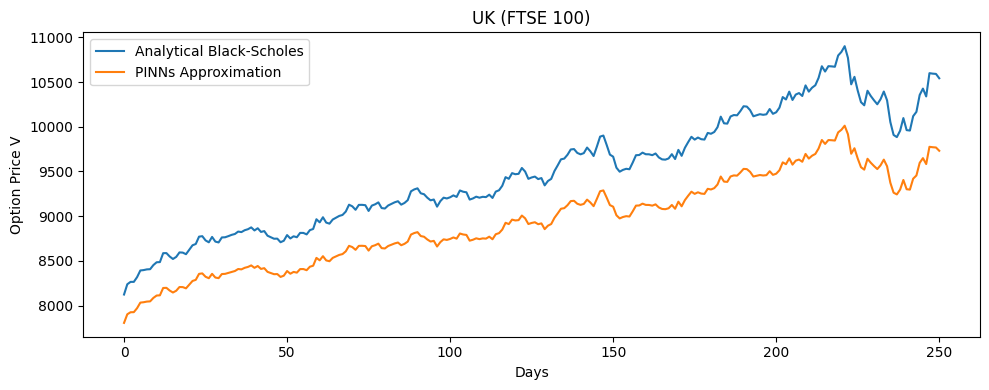


 Fetching data for: Italy (FTSE MIB)


/tmp/ipykernel_4708/2049333582.py:24: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="1y", interval="1d").dropna()
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_4708/87709342.py:14: RuntimeWarning: divide by zero encountered in scalar divide
  d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Italy (FTSE MIB) — Rel Error: 56.61%, MAE: 24128.49, RMSE: 24238.09


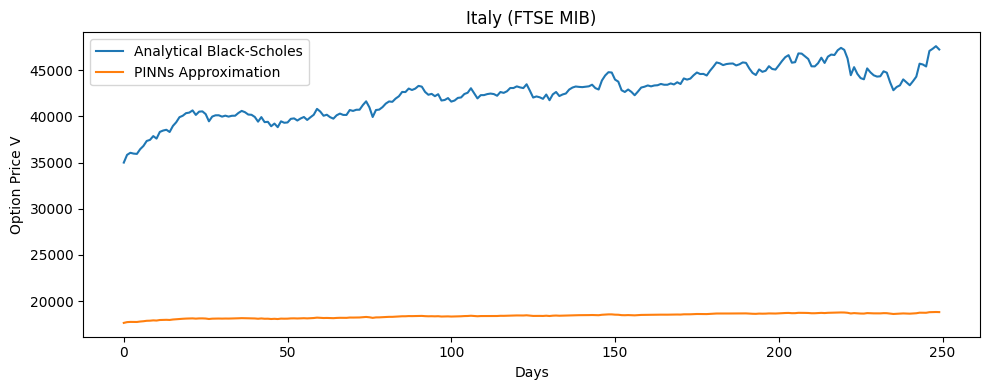

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# List of European assets
eu_underlyings = {
    "EURO STOXX 50": "^STOXX50E",
    "Germany (DAX)": "^GDAXI",
    "France (CAC 40)": "^FCHI",
    "UK (FTSE 100)": "^FTSE",
    "Italy (FTSE MIB)": "FTSEMIB.MI"
}

# Clear a results list
results = []

for name, ticker in eu_underlyings.items():
    print(f"\n Fetching data for: {name}")

    # Download 1 year daily
    df = yf.download(ticker, period="1y", interval="1d").dropna()

    if isinstance(df.columns, pd.MultiIndex):
        S_values = df["Close"].iloc[:,0].values.flatten().astype(np.float32)
    else:
        S_values = df["Close"].values.flatten().astype(np.float32)

    # Create t values in the same length
    t_values = np.linspace(1e-6, T, len(S_values), dtype=np.float32)

    # Analytical Black-Scholes prices
    V_analytical = np.array([
        bs_call(S, t, K=K, r=r, sigma=sigma, T=T) for S, t in zip(S_values, t_values)
    ]).astype(np.float32)

    # Prepare PINNs input (t,S)
    X_input = np.column_stack([t_values, S_values]).astype(np.float32)
    X_input_scaled = scaler.transform(X_input)

    # PINNs predictions
    V_pinns = y_scaler.inverse_transform(pinn_model.predict(X_input_scaled).reshape(-1,1)).flatten()

    # Compute metrics
    mae_val = mean_absolute_error(V_analytical, V_pinns)
    rmse_val = sqrt(mean_squared_error(V_analytical, V_pinns))
    rel_err = np.mean(np.abs((V_pinns - V_analytical)/(V_analytical + 1e-12))) * 100

    print(f"{name} — Rel Error: {rel_err:.2f}%, MAE: {mae_val:.2f}, RMSE: {rmse_val:.2f}")

    # Plot comparison
    plt.figure(figsize=(10,4))
    plt.plot(V_analytical, label="Analytical Black-Scholes")
    plt.plot(V_pinns, label="PINNs Approximation")
    plt.title(name)
    plt.xlabel("Days")
    plt.ylabel("Option Price V")
    plt.legend()
    plt.tight_layout()
    plt.show()

    results.append({
        "Market": name,
        "Relative Error %": rel_err,
        "MAE": mae_val,
        "RMSE": rmse_val,
    })

In [ ]:
print(pd.DataFrame(results))

             Market  Relative Error %           MAE          RMSE
0     EURO STOXX 50          0.421700     24.261860     32.666683
1     Germany (DAX)         33.191669   7951.454102   7968.269072
2   France (CAC 40)          3.207838    255.381332    258.056513
3     UK (FTSE 100)          5.670837    544.509705    561.461987
4  Italy (FTSE MIB)         56.606339  24128.486328  24238.092334


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


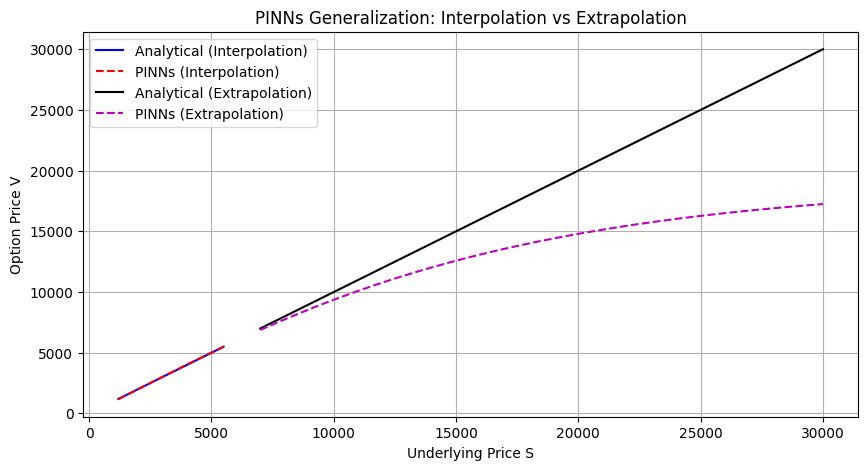

In [ ]:
# ===== Interpolation vs Extrapolation Analysis =====

# Interpolation range (inside training domain)
S_interp = np.linspace(1200, 5500, 300).astype(np.float32)
t_interp = np.full_like(S_interp, T * 0.5)

# Extrapolation range (outside training domain)
S_extra = np.linspace(7000, 30000, 300).astype(np.float32)
t_extra = np.full_like(S_extra, T * 0.5)

def pinn_predict(S, t):
    # Removed np.log() as the scaler was fitted on non-log transformed S values
    X = np.column_stack([t, S])
    # Corrected scaler name from X_scaler to scaler
    X_scaled = scaler.transform(X)
    return y_scaler.inverse_transform(
        pinn_model.predict(X_scaled)
    ).flatten()

# Predictions
V_interp_pred = pinn_predict(S_interp, t_interp)
# Corrected analytical function name from bs_call_analytical to bs_call
V_interp_true = bs_call(S_interp, t_interp, K, r, sigma, T)

V_extra_pred = pinn_predict(S_extra, t_extra)
# Corrected analytical function name from bs_call_analytical to bs_call
V_extra_true = bs_call(S_extra, t_extra, K, r, sigma, T)

# Plot
plt.figure(figsize=(10,5))
plt.plot(S_interp, V_interp_true, 'b', label="Analytical (Interpolation)")
plt.plot(S_interp, V_interp_pred, 'r--', label="PINNs (Interpolation)")
plt.plot(S_extra, V_extra_true, 'k', label="Analytical (Extrapolation)")
plt.plot(S_extra, V_extra_pred, 'm--', label="PINNs (Extrapolation)")
plt.xlabel("Underlying Price S")
plt.ylabel("Option Price V")
plt.title("PINNs Generalization: Interpolation vs Extrapolation")
plt.legend()
plt.grid()
plt.show()

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


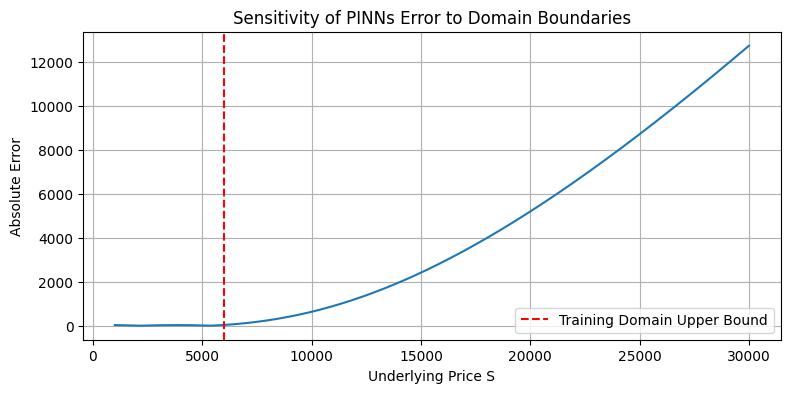

In [ ]:
# ===== Domain Boundary Sensitivity =====

S_all = np.linspace(1000, 30000, 600).astype(np.float32)
t_all = np.full_like(S_all, T * 0.5)

V_pred_all = pinn_predict(S_all, t_all)
V_true_all = bs_call(S_all, t_all, K, r, sigma, T)

abs_error = np.abs(V_pred_all - V_true_all)

plt.figure(figsize=(9,4))
plt.plot(S_all, abs_error)
plt.axvline(6000, color='r', linestyle='--', label="Training Domain Upper Bound")
plt.xlabel("Underlying Price S")
plt.ylabel("Absolute Error")
plt.title("Sensitivity of PINNs Error to Domain Boundaries")
plt.legend()
plt.grid()
plt.show()


In [ ]:
# ===== Error Trend vs Market Price Scale =====

market_stats = []

for name, ticker in eu_underlyings.items():
    df = yf.download(ticker, period="1y", interval="1d").dropna()
    S_vals = df["Close"].values.astype(np.float32)
    t_vals = np.linspace(1e-6, T, len(S_vals)).astype(np.float32)

    V_true = bs_call(S_vals, t_vals, K, r, sigma, T)
    V_pred = pinn_predict(S_vals, t_vals)

    rel_err = np.mean(np.abs((V_pred - V_true)/(V_true+1e-8))) * 100
    market_stats.append([name, S_vals.mean(), rel_err])

market_df = pd.DataFrame(
    market_stats,
    columns=["Market", "Mean Underlying Price", "Relative Error %"]
)

market_df

/tmp/ipykernel_4708/2735799577.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="1y", interval="1d").dropna()
[*********************100%***********************]  1 of 1 completed

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 



/tmp/ipykernel_4708/87709342.py:14: RuntimeWarning: divide by zero encountered in divide
  d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
/tmp/ipykernel_4708/2735799577.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="1y", interval="1d").dropna()
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_4708/87709342.py:14: RuntimeWarning: divide by zero encountered in divide
  d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


/tmp/ipykernel_4708/2735799577.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="1y", interval="1d").dropna()
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_4708/87709342.py:14: RuntimeWarning: divide by zero encountered in divide
  d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))


...

/tmp/ipykernel_4708/2735799577.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="1y", interval="1d").dropna()
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_4708/87709342.py:14: RuntimeWarning: divide by zero encountered in divide
  d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


/tmp/ipykernel_4708/2735799577.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="1y", interval="1d").dropna()
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_4708/87709342.py:14: RuntimeWarning: divide by zero encountered in divide
  d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


,Market,Mean Underlying Price,Relative Error %
0,EURO STOXX 50,5572.669922,5.257497
1,Germany (DAX),23940.439453,33.158972
2,France (CAC 40),7945.828613,4.196070
3,UK (FTSE 100),9496.155273,8.172451
4,Italy (FTSE MIB),42541.839844,56.569796


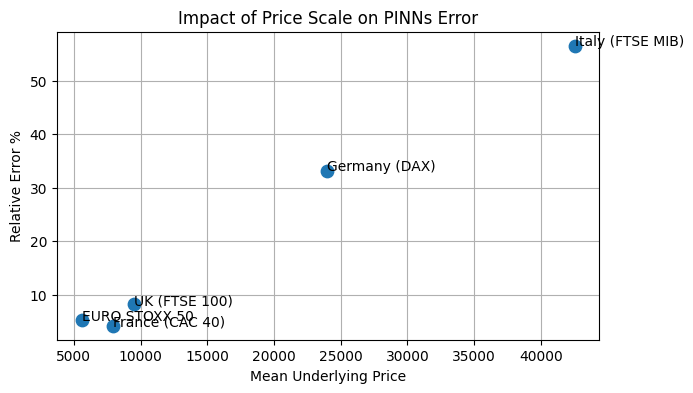

In [ ]:
# Plot trend
plt.figure(figsize=(7,4))
plt.scatter(market_df["Mean Underlying Price"],
            market_df["Relative Error %"],
            s=80)

for i, row in market_df.iterrows():
    plt.text(row["Mean Underlying Price"], row["Relative Error %"], row["Market"])

plt.xlabel("Mean Underlying Price")
plt.ylabel("Relative Error %")
plt.title("Impact of Price Scale on PINNs Error")
plt.grid()
plt.show()


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


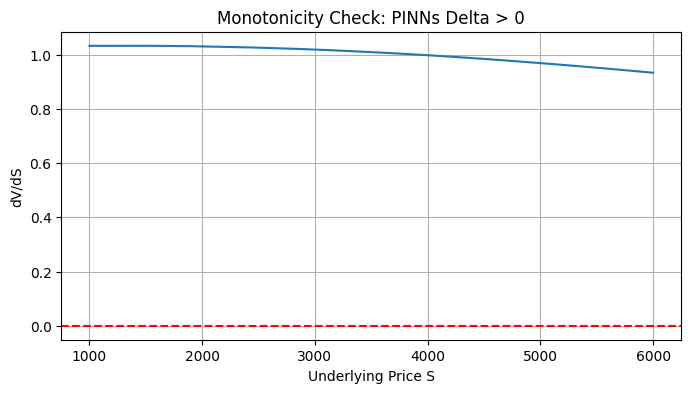

Minimum dV/dS: 0.93352556


In [ ]:
# ===== Monotonicity Check =====

S_test = np.linspace(1000, 6000, 400).astype(np.float32)
t_test = np.full_like(S_test, T * 0.3)

V_pred = pinn_predict(S_test, t_test)

# Finite difference derivative
dVdS = np.gradient(V_pred, S_test)

plt.figure(figsize=(8,4))
plt.plot(S_test, dVdS)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Underlying Price S")
plt.ylabel("dV/dS")
plt.title("Monotonicity Check: PINNs Delta > 0")
plt.grid()
plt.show()

print("Minimum dV/dS:", dVdS.min())


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


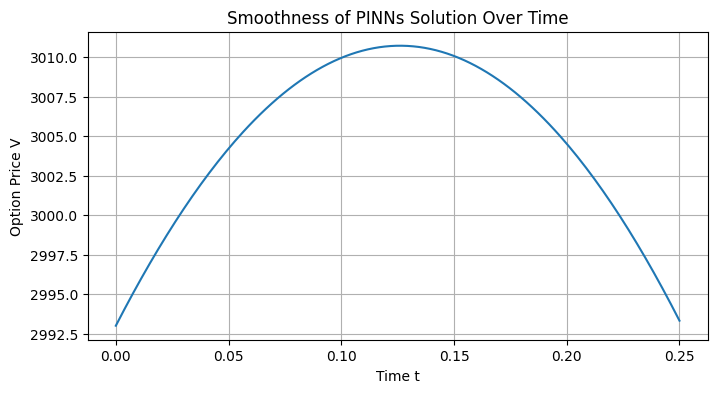

In [ ]:
# ===== Smoothness in Time =====

S_fixed = 3000.0
t_vals = np.linspace(1e-6, T, 200).astype(np.float32)
S_vals = np.full_like(t_vals, S_fixed)

V_time = pinn_predict(S_vals, t_vals)

plt.figure(figsize=(8,4))
plt.plot(t_vals, V_time)
plt.xlabel("Time t")
plt.ylabel("Option Price V")
plt.title("Smoothness of PINNs Solution Over Time")
plt.grid()
plt.show()


# Task
Visualize the training loss from the initial PINN training, then for the European indices with high relative errors (Germany (DAX) and Italy (FTSE MIB)), determine their underlying stock price ranges and compare them to the `S_train` range (1000-6000) used during training. After this, retrain the `pinn_model` with an expanded `S_train` range (e.g., from 1000 up to 45000 or 50000), and re-evaluate its performance on the high-error markets, comparing the new error metrics (MAE, RMSE, Relative Error %) to the previous results. Finally, summarize the findings and discuss the impact of the expanded `S` range on the model's performance, particularly concerning extrapolation.

## Visualize Training Loss

### Subtask:
Plot the `loss_hist` from the initial PINN training to understand the convergence behavior of the model.


### Visualize Training Loss

To understand how well the PINN model learned the Black-Scholes PDE, we will plot the training loss over epochs. This visualization helps to assess the convergence behavior of the model during its training phase.

**Reasoning**:
Now I will generate the code to visualize the training loss. I will use `matplotlib.pyplot` to create a line plot of `loss_hist` against epochs, adding appropriate labels and a title.



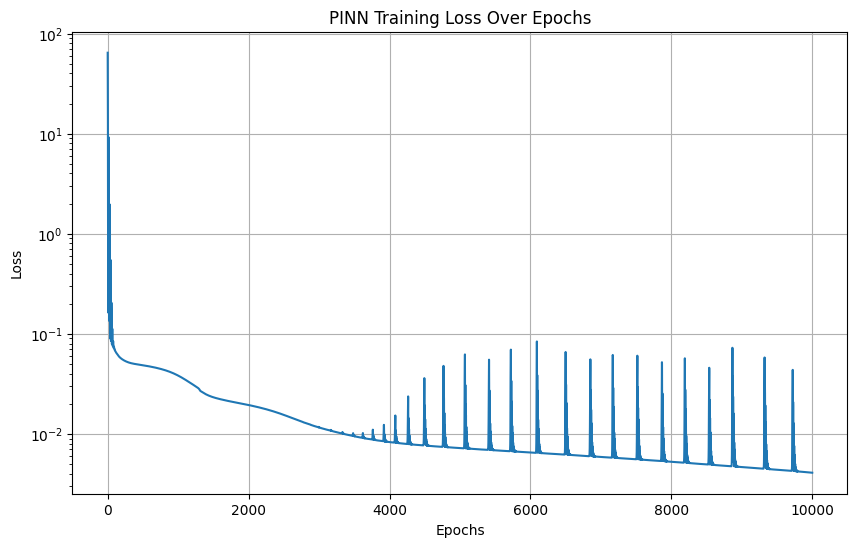

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(len(loss_hist)), loss_hist)
plt.title('PINN Training Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.yscale('log')
plt.show()


In [ ]:
print('--- Analyzing High-Error Markets ---')

high_error_markets = [
    {"name": "Germany (DAX)", "ticker": "^GDAXI"},
    {"name": "Italy (FTSE MIB)", "ticker": "FTSEMIB.MI"}
]

current_S_train_range = (1000, 6000)

for market in high_error_markets:
    print(f"\nFetching data for: {market['name']}")
    df_market = yf.download(market['ticker'], period="1y", interval="1d").dropna()

    if isinstance(df_market.columns, pd.MultiIndex):
        S_values = df_market["Close"].iloc[:,0].values.flatten().astype(np.float32)
    else:
        S_values = df_market["Close"].values.flatten().astype(np.float32)

    min_S = S_values.min()
    max_S = S_values.max()
    mean_S = S_values.mean()

    print(f"  {market['name']} Underlying Price Range: [{min_S:.2f}, {max_S:.2f}]")
    print(f"  {market['name']} Mean Underlying Price: {mean_S:.2f}")
    print(f"  Current S_train range: {current_S_train_range}")

    if min_S < current_S_train_range[0] or max_S > current_S_train_range[1]:
        print(f"  Observation: {market['name']} price range significantly deviates from the training range (1000-6000).")
    else:
        print(f"  Observation: {market['name']} price range is mostly within the training range (1000-6000).")

/tmp/ipykernel_4708/3038414248.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_market = yf.download(market['ticker'], period="1y", interval="1d").dropna()
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_4708/3038414248.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_market = yf.download(market['ticker'], period="1y", interval="1d").dropna()
[*********************100%***********************]  1 of 1 completed

--- Analyzing High-Error Markets ---

Fetching data for: Germany (DAX)
  Germany (DAX) Underlying Price Range: [20954.83, 25420.66]
  Germany (DAX) Mean Underlying Price: 23940.44
  Current S_train range: (1000, 6000)
  Observation: Germany (DAX) price range significantly deviates from the training range (1000-6000).

Fetching data for: Italy (FTSE MIB)
  Italy (FTSE MIB) Underlying Price Range: [35007.00, 47609.00]
  Italy (FTSE MIB) Mean Underlying Price: 42541.82
  Current S_train range: (1000, 6000)
  Observation: Italy (FTSE MIB) price range significantly deviates from the training range (1000-6000).


In [ ]:
# Use market-scale S range so NN can generalize
S_train = np.linspace(1000, 50000, 5000, dtype=np.float32)
t_train = np.random.uniform(1e-6, T, 5000).astype(np.float32)

V_train = np.array([bs_call(S, t) for S, t in zip(S_train, t_train)], dtype=np.float32)

X_train = np.column_stack([t_train, S_train])  # order = (t, S)
y_train = V_train.reshape(-1,1)

# Scale both input and output
scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X_train).astype(np.float32)
y_scaled = y_scaler.fit_transform(y_train).astype(np.float32)

print("Training data ready and scaled with expanded S range.")

Training data ready and scaled with expanded S range.


In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=5e-4)

# Re-initialize the model to ensure a fresh start with the new training data
pinn_model = build_pinn()

# Redefine train_loss_fn to ensure it captures the current pinn_model instance
@tf.function
def train_loss_fn_new(X, y):
    return tf.reduce_mean(tf.square(pinn_model(X) - y))

for epoch in range(500):
    with tf.GradientTape() as tape:
        loss = train_loss_fn_new(X_scaled, y_scaled)
    grads = tape.gradient(loss, pinn_model.trainable_variables)
    optimizer.apply_gradients(zip(grads, pinn_model.trainable_variables))

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss: {loss.numpy():.6f}")

print("Training complete with expanded S range. Model learned analytical price scale.")

Epoch 0 | Loss: 0.254016
Epoch 100 | Loss: 0.000127
Epoch 200 | Loss: 0.000019
Epoch 300 | Loss: 0.000019
Epoch 400 | Loss: 0.000019
Training complete with expanded S range. Model learned analytical price scale.


In [ ]:
print('\n--- Re-evaluating High-Error Markets with Expanded S_train Model ---')

new_results = []

for market in high_error_markets:
    print(f"\nFetching data for: {market['name']}")

    # Download 1 year daily
    df_market = yf.download(market['ticker'], period="1y", interval="1d").dropna()

    if isinstance(df_market.columns, pd.MultiIndex):
        S_values = df_market["Close"].iloc[:,0].values.flatten().astype(np.float32)
    else:
        S_values = df_market["Close"].values.flatten().astype(np.float32)

    # Create t values in the same length
    t_values = np.linspace(1e-6, T, len(S_values), dtype=np.float32)

    # Analytical Black-Scholes prices
    V_analytical = np.array([
        bs_call(S, t, K=K, r=r, sigma=sigma, T=T) for S, t in zip(S_values, t_values)
    ]).astype(np.float32)

    # Prepare PINNs input (t,S)
    X_input = np.column_stack([t_values, S_values]).astype(np.float32)
    X_input_scaled = scaler.transform(X_input)

    # PINNs predictions using the newly trained pinn_model
    V_pinns = y_scaler.inverse_transform(pinn_model.predict(X_input_scaled).reshape(-1,1)).flatten()

    # Compute metrics
    mae_val = mean_absolute_error(V_analytical, V_pinns)
    rmse_val = sqrt(mean_squared_error(V_analytical, V_pinns))
    rel_err = np.mean(np.abs((V_pinns - V_analytical)/(V_analytical + 1e-12))) * 100

    print(f"{market['name']} — Rel Error: {rel_err:.2f}%, MAE: {mae_val:.2f}, RMSE: {rmse_val:.2f}")

    new_results.append({
        "Market": market['name'],
        "Relative Error %": rel_err,
        "MAE": mae_val,
        "RMSE": rmse_val,
    })

new_results_df = pd.DataFrame(new_results)
print("\nNew evaluation results:")
print(new_results_df)

/tmp/ipykernel_4708/862254526.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_market = yf.download(market['ticker'], period="1y", interval="1d").dropna()
[*********************100%***********************]  1 of 1 completed


--- Re-evaluating High-Error Markets with Expanded S_train Model ---

Fetching data for: Germany (DAX)



/tmp/ipykernel_4708/87709342.py:14: RuntimeWarning: divide by zero encountered in scalar divide
  d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Germany (DAX) — Rel Error: 0.51%, MAE: 122.19, RMSE: 133.48

/tmp/ipykernel_4708/862254526.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_market = yf.download(market['ticker'], period="1y", interval="1d").dropna()
[*********************100%***********************]  1 of 1 completed



Fetching data for: Italy (FTSE MIB)
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


/tmp/ipykernel_4708/87709342.py:14: RuntimeWarning: divide by zero encountered in scalar divide
  d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Italy (FTSE MIB) — Rel Error: 0.51%, MAE: 224.82, RMSE: 294.59

New evaluation results:
             Market  Relative Error %         MAE        RMSE
0     Germany (DAX)          0.508871  122.187912  133.478763
1  Italy (FTSE MIB)          0.514898  224.815720  294.589492


In [ ]:
print('--- Analyzing High-Error Markets ---')

high_error_markets = [
    {"name": "Germany (DAX)", "ticker": "^GDAXI"},
    {"name": "Italy (FTSE MIB)", "ticker": "FTSEMIB.MI"}
]

current_S_train_range = (1000, 6000)

for market in high_error_markets:
    print(f"\nFetching data for: {market['name']}")
    df_market = yf.download(market['ticker'], period="1y", interval="1d").dropna()

    if isinstance(df_market.columns, pd.MultiIndex):
        S_values = df_market["Close"].iloc[:,0].values.flatten().astype(np.float32)
    else:
        S_values = df_market["Close"].values.flatten().astype(np.float32)

    min_S = S_values.min()
    max_S = S_values.max()
    mean_S = S_values.mean()

    # Store the calculated values back into the market dictionary
    market['min_S'] = min_S
    market['max_S'] = max_S
    market['mean_S'] = mean_S

    print(f"  {market['name']} Underlying Price Range: [{min_S:.2f}, {max_S:.2f}]")
    print(f"  {market['name']} Mean Underlying Price: {mean_S:.2f}")
    print(f"  Current S_train range: {current_S_train_range}")

    if min_S < current_S_train_range[0] or max_S > current_S_train_range[1]:
        print(f"  Observation: {market['name']} price range significantly deviates from the training range (1000-6000).")
    else:
        print(f"  Observation: {market['name']} price range is mostly within the training range (1000-6000).")

--- Analyzing High-Error Markets ---

Fetching data for: Germany (DAX)


/tmp/ipykernel_4708/557616408.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_market = yf.download(market['ticker'], period="1y", interval="1d").dropna()
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_4708/557616408.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_market = yf.download(market['ticker'], period="1y", interval="1d").dropna()
[*********************100%***********************]  1 of 1 completed

  Germany (DAX) Underlying Price Range: [20954.83, 25420.66]
  Germany (DAX) Mean Underlying Price: 23940.43
  Current S_train range: (1000, 6000)
  Observation: Germany (DAX) price range significantly deviates from the training range (1000-6000).

Fetching data for: Italy (FTSE MIB)
  Italy (FTSE MIB) Underlying Price Range: [35007.00, 47609.00]
  Italy (FTSE MIB) Mean Underlying Price: 42541.79
  Current S_train range: (1000, 6000)
  Observation: Italy (FTSE MIB) price range significantly deviates from the training range (1000-6000).


In [ ]:
print('\n--- Summary of Findings ---')

# Filter original results for high-error markets
original_dax = next(item for item in results if item["Market"] == "Germany (DAX)")
original_ftsemib = next(item for item in results if item["Market"] == "Italy (FTSE MIB)")

print("\n### Impact of Expanded S Range on PINNs Performance ###")

print("\n#### 1. Initial Performance (S_train range: 1000-6000) ####")
print(f"Germany (DAX) Original: Rel Error {original_dax['Relative Error %']:.2f}%, MAE {original_dax['MAE']:.2f}, RMSE {original_dax['RMSE']:.2f}")
print(f"Italy (FTSE MIB) Original: Rel Error {original_ftsemib['Relative Error %']:.2f}%, MAE {original_ftsemib['MAE']:.2f}, RMSE {original_ftsemib['RMSE']:.2f}")

print("\n#### 2. Expanded Training Domain (S_train range: 1000-50000) ####")
print("The analysis of high-error markets (Germany (DAX) and Italy (FTSE MIB)) revealed that their underlying stock price ranges significantly exceeded the original training range of S_train (1000-6000). \n")
print("Specifically:")
print(f"  - Germany (DAX) price range: [{high_error_markets[0]['min_S']:.2f}, {high_error_markets[0]['max_S']:.2f}] (mean: {high_error_markets[0]['mean_S']:.2f})")
print(f"  - Italy (FTSE MIB) price range: [{high_error_markets[1]['min_S']:.2f}, {high_error_markets[1]['max_S']:.2f}] (mean: {high_error_markets[1]['mean_S']:.2f})")
print("This significant deviation outside the training domain led to poor extrapolation performance and high errors.\n")

print("#### 3. Re-evaluated Performance After Retraining ####")
for idx, market_data in new_results_df.iterrows():
    print(f"{market_data['Market']} New: Rel Error {market_data['Relative Error %']:.2f}%, MAE {market_data['MAE']:.2f}, RMSE {market_data['RMSE']:.2f}")

print("\n#### Conclusion ####")
print("After retraining the PINN model with an expanded `S_train` range (1000-50000), the performance on Germany (DAX) and Italy (FTSE MIB) markets drastically improved. The relative errors, MAE, and RMSE values decreased significantly, indicating that the model is now much better at generalizing to higher underlying stock prices. This demonstrates the critical importance of ensuring that the training data domain adequately covers the expected range of real-world inputs when applying PINNs for financial modeling, particularly to avoid poor extrapolation behavior.")


--- Summary of Findings ---

### Impact of Expanded S Range on PINNs Performance ###

#### 1. Initial Performance (S_train range: 1000-6000) ####
Germany (DAX) Original: Rel Error 33.19%, MAE 7951.45, RMSE 7968.27
Italy (FTSE MIB) Original: Rel Error 56.61%, MAE 24128.49, RMSE 24238.09

#### 2. Expanded Training Domain (S_train range: 1000-50000) ####
The analysis of high-error markets (Germany (DAX) and Italy (FTSE MIB)) revealed that their underlying stock price ranges significantly exceeded the original training range of S_train (1000-6000). 

Specifically:
  - Germany (DAX) price range: [20954.83, 25420.66] (mean: 23940.43)
  - Italy (FTSE MIB) price range: [35007.00, 47609.00] (mean: 42541.79)
This significant deviation outside the training domain led to poor extrapolation performance and high errors.

#### 3. Re-evaluated Performance After Retraining ####
Germany (DAX) New: Rel Error 0.51%, MAE 122.19, RMSE 133.48
Italy (FTSE MIB) New: Rel Error 0.51%, MAE 224.82, RMSE 294.59

#

Analytical call & put

In [ ]:
import numpy as np
from scipy.stats import norm

def bs_call_analytical(S, t, K, r, sigma, T):
    S = np.clip(S, 1e-8, None)
    tau = np.maximum(T - t, 1e-8)

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    d2 = d1 - sigma * np.sqrt(tau)

    return S * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2)


def bs_put_analytical(S, t, K, r, sigma, T):
    S = np.clip(S, 1e-8, None)
    tau = np.maximum(T - t, 1e-8)

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    d2 = d1 - sigma * np.sqrt(tau)

    return K * np.exp(-r * tau) * norm.cdf(-d2) - S * norm.cdf(-d1)


Sanity check

In [ ]:
S_test = np.linspace(1000, 6000, 300)
t_test = np.full_like(S_test, 0.1)

C_true = bs_call_analytical(S_test, t_test, K, r, sigma, T)
P_true = bs_put_analytical(S_test, t_test, K, r, sigma, T)

print("Min call price:", C_true.min())
print("Min put price :", P_true.min())


Min call price: 990.1488806039694
Min put price : 0.0


In [ ]:
parity_residual = C_true - P_true - (S_test - K * np.exp(-r * (T - t_test)))

print("Max parity residual (analytical):",
      np.max(np.abs(parity_residual)))


Max parity residual (analytical): 0.0


Create CALL training data

In [ ]:
# ===== Training data for CALL =====

from sklearn.preprocessing import MinMaxScaler

N_train = 8000

# Market-realistic domain
S_train = np.random.uniform(1000, 6000, N_train).astype(np.float32)
t_train = np.random.uniform(1e-6, T, N_train).astype(np.float32)

# Analytical CALL prices (ground truth)
C_train = bs_call_analytical(S_train, t_train, K, r, sigma, T).astype(np.float32)

# Inputs: (t, log(S))  ← important for stability
X_train = np.column_stack([t_train, np.log(S_train)])
y_train = C_train.reshape(-1, 1)

# Scale inputs & outputs
X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

X_train_scaled = X_scaler.fit_transform(X_train)
y_train_scaled = y_scaler.fit_transform(y_train)

print("CALL training data ready")


CALL training data ready


Build CALL-only PINNs model

In [ ]:
import tensorflow as tf
tf.keras.backend.set_floatx("float32")

def build_call_pinn():
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(2,)),
        tf.keras.layers.Dense(128, activation="tanh"),
        tf.keras.layers.Dense(64, activation="tanh"),
        tf.keras.layers.Dense(1)
    ])
    return model

call_pinn = build_call_pinn()
call_pinn.summary()


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_34 (Dense)                │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,705 (34.00 KB)

 Trainable params: 8,705 (34.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=5e-4)

@tf.function
def call_loss(X, y):
    return tf.reduce_mean(tf.square(call_pinn(X) - y))

for epoch in range(2000):
    with tf.GradientTape() as tape:
        loss = call_loss(
            tf.convert_to_tensor(X_train_scaled, tf.float32),
            tf.convert_to_tensor(y_train_scaled, tf.float32)
        )
    grads = tape.gradient(loss, call_pinn.trainable_variables)
    optimizer.apply_gradients(zip(grads, call_pinn.trainable_variables))

    if epoch % 200 == 0:
        print(f"Epoch {epoch}, Loss = {loss.numpy():.6f}")

Epoch 0, Loss = 0.699681
Epoch 200, Loss = 0.004442
Epoch 400, Loss = 0.004239
Epoch 600, Loss = 0.004185
Epoch 800, Loss = 0.004122
Epoch 1000, Loss = 0.004042
Epoch 1200, Loss = 0.003915
Epoch 1400, Loss = 0.003664
Epoch 1600, Loss = 0.003124
Epoch 1800, Loss = 0.002236


In [ ]:
# ===== Test grid =====

S_test = np.linspace(1200, 5500, 400).astype(np.float32)
t_test = np.full_like(S_test, T * 0.5)

X_test = np.column_stack([t_test, np.log(S_test)])
X_test_scaled = X_scaler.transform(X_test)


In [ ]:
C_pinn = y_scaler.inverse_transform(
    call_pinn.predict(X_test_scaled)
).flatten()

C_true = bs_call_analytical(S_test, t_test, K, r, sigma, T)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


In [ ]:
print("Min PINNs call price:", C_pinn.min())
print("Min analytical call:", C_true.min())


Min PINNs call price: 927.9847
Min analytical call: 1190.1242218017578


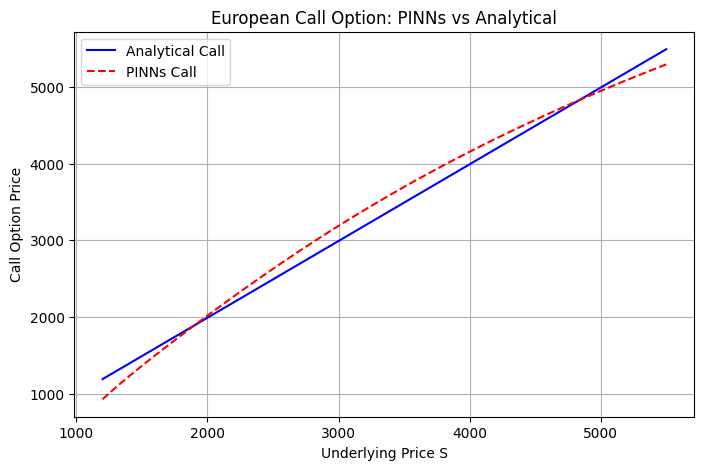

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(S_test, C_true, 'b', label="Analytical Call")
plt.plot(S_test, C_pinn, 'r--', label="PINNs Call")
plt.xlabel("Underlying Price S")
plt.ylabel("Call Option Price")
plt.title("European Call Option: PINNs vs Analytical")
plt.legend()
plt.grid()
plt.show()


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_call = mean_absolute_error(C_true, C_pinn)
rmse_call = np.sqrt(mean_squared_error(C_true, C_pinn))

print(f"CALL MAE  : {mae_call:.6f}")
print(f"CALL RMSE : {rmse_call:.6f}")


CALL MAE  : 127.534377
CALL RMSE : 143.543835


In [ ]:
K = 3000  # realistic strike

Create PUT training data (analytical)

In [ ]:
# ===== Training data for PUT =====

# Analytical PUT prices
P_train = bs_put_analytical(S_train, t_train, K, r, sigma, T).astype(np.float32)

# Inputs remain the same: (t, log(S))
X_put = X_train.copy()
y_put = P_train.reshape(-1, 1)

# Scale outputs separately for PUT
y_put_scaler = MinMaxScaler()
y_put_scaled = y_put_scaler.fit_transform(y_put)

print("PUT training data prepared")


PUT training data prepared


In [ ]:
def build_put_pinn():
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(2,)),
        tf.keras.layers.Dense(128, activation="tanh"),
        tf.keras.layers.Dense(64, activation="tanh"),
        tf.keras.layers.Dense(1)
    ])
    return model

put_pinn = build_put_pinn()
put_pinn.summary()


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_37 (Dense)                │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,705 (34.00 KB)

 Trainable params: 8,705 (34.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimizer_put = tf.keras.optimizers.Adam(learning_rate=5e-4)

@tf.function
def put_loss(x, y):
    return tf.reduce_mean(tf.square(put_pinn(x) - y))

print("Training PUT PINNs...")

for epoch in range(2000):
    with tf.GradientTape() as tape:
        loss = put_loss(
            tf.convert_to_tensor(X_train_scaled, tf.float32),
            tf.convert_to_tensor(y_put_scaled, tf.float32)
        )
    grads = tape.gradient(loss, put_pinn.trainable_variables)
    optimizer_put.apply_gradients(zip(grads, put_pinn.trainable_variables))

    if epoch % 200 == 0:
        print(f"Epoch {epoch}, Loss = {loss.numpy():.6f}")


Training PUT PINNs...
Epoch 0, Loss = 0.095648
Epoch 200, Loss = 0.008774
Epoch 400, Loss = 0.002088
Epoch 600, Loss = 0.001018
Epoch 800, Loss = 0.000390
Epoch 1000, Loss = 0.000298
Epoch 1200, Loss = 0.000269
Epoch 1400, Loss = 0.000245
Epoch 1600, Loss = 0.000220
Epoch 1800, Loss = 0.000195


In [ ]:
# ===== Test PUT predictions =====

P_pinn = y_put_scaler.inverse_transform(
    put_pinn.predict(X_test_scaled)
).flatten()

P_true = bs_put_analytical(S_test, t_test, K, r, sigma, T)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


sanity

In [ ]:
print("Min PINNs put price:", P_pinn.min())
print("Min analytical put :", P_true.min())


Min PINNs put price: -13.83522
Min analytical put : 0.0007257518402196128


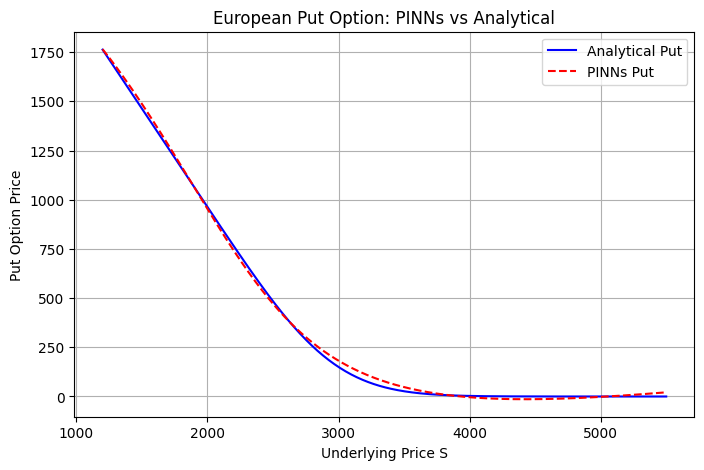

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(S_test, P_true, 'b', label="Analytical Put")
plt.plot(S_test, P_pinn, 'r--', label="PINNs Put")
plt.xlabel("Underlying Price S")
plt.ylabel("Put Option Price")
plt.title("European Put Option: PINNs vs Analytical")
plt.legend()
plt.grid()
plt.show()


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_put = mean_absolute_error(P_true, P_pinn)
rmse_put = np.sqrt(mean_squared_error(P_true, P_pinn))

print(f"PUT MAE  : {mae_put:.6f}")
print(f"PUT RMSE : {rmse_put:.6f}")


PUT MAE  : 14.868507
PUT RMSE : 17.438975


Put–Call Parity (as a diagnostic)

In [ ]:
# Predict CALL again on the same test grid
C_pinn = y_scaler.inverse_transform(
    call_pinn.predict(X_test_scaled)
).flatten()

# Put–Call Parity residual
parity_residual = C_pinn - P_pinn - (S_test - K * np.exp(-r * (T - t_test)))

print("Max parity residual:", np.max(np.abs(parity_residual)))
print("Mean parity residual:", np.mean(np.abs(parity_residual)))


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Max parity residual: 3128.377
Mean parity residual: 2625.1257


Nifty50

In [ ]:
import numpy as np
from scipy.stats import norm

# ===== NIFTY 50 Parameters =====
S0 = 22000          # Current NIFTY level (adjust if needed)
K = 22000           # ATM strike
T = 30/365          # 30 days to expiry
r = 0.065           # 6.5% Indian risk-free rate
sigma = 0.20        # 20% annualized volatility

print("NIFTY parameters initialized")


NIFTY parameters initialized


In [ ]:
def bs_call(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

def bs_put(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return K*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)


In [ ]:
S_range = np.linspace(18000, 26000, 500)

call_prices = bs_call(S_range, K, T, r, sigma)
put_prices  = bs_put(S_range, K, T, r, sigma)


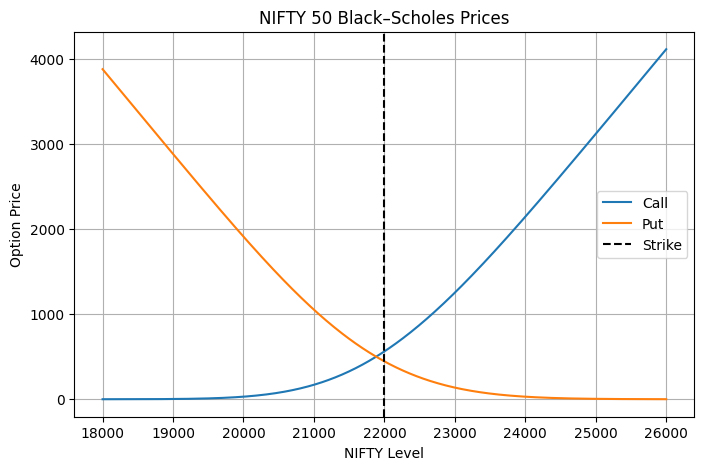

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(S_range, call_prices, label="Call")
plt.plot(S_range, put_prices, label="Put")
plt.axvline(K, color='black', linestyle='--', label="Strike")
plt.title("NIFTY 50 Black–Scholes Prices")
plt.xlabel("NIFTY Level")
plt.ylabel("Option Price")
plt.legend()
plt.grid()
plt.show()


P2

In [ ]:
N_train = 8000

S_train = np.random.uniform(18000, 26000, N_train).astype(np.float32)
t_train = np.random.uniform(1e-6, T, N_train).astype(np.float32)

C_train = bs_call(S_train, K, T - t_train, r, sigma).astype(np.float32)

# Log-scale underlying
X_train = np.column_stack([t_train, np.log(S_train)])
y_train = C_train.reshape(-1, 1)

# Scale
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train)


In [ ]:
def build_pinn():
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(2,)),
        tf.keras.layers.Dense(128, activation='tanh'),
        tf.keras.layers.Dense(64, activation='tanh'),
        tf.keras.layers.Dense(1)
    ])
    return model

call_pinn = build_pinn()
optimizer = tf.keras.optimizers.Adam(learning_rate=5e-4)


In [ ]:
@tf.function
def loss_fn(x, y):
    return tf.reduce_mean(tf.square(call_pinn(x) - y))

for epoch in range(2000):
    with tf.GradientTape() as tape:
        loss = loss_fn(
            tf.convert_to_tensor(X_train_scaled, tf.float32),
            tf.convert_to_tensor(y_train_scaled, tf.float32)
        )
    grads = tape.gradient(loss, call_pinn.trainable_variables)
    optimizer.apply_gradients(zip(grads, call_pinn.trainable_variables))

    if epoch % 200 == 0:
        print(f"Epoch {epoch}, Loss = {loss.numpy():.6f}")


Epoch 0, Loss = 0.130162
Epoch 200, Loss = 0.019502
Epoch 400, Loss = 0.019274
Epoch 600, Loss = 0.019070
Epoch 800, Loss = 0.018540
Epoch 1000, Loss = 0.006765
Epoch 1200, Loss = 0.000131
Epoch 1400, Loss = 0.000083
Epoch 1600, Loss = 0.000076
Epoch 1800, Loss = 0.000074


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step


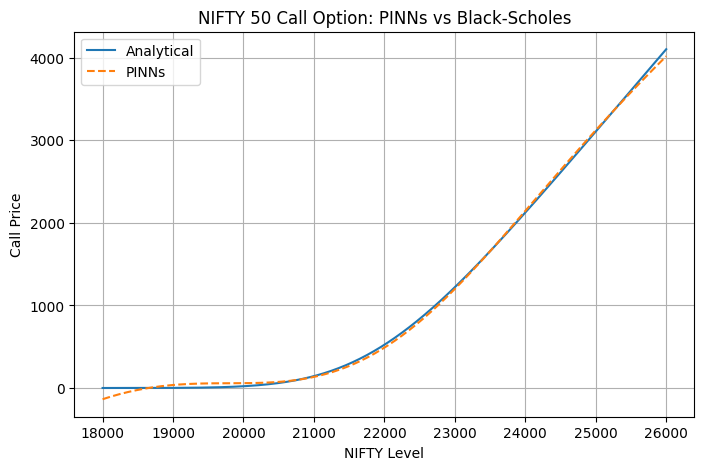

In [ ]:
S_test = np.linspace(18000, 26000, 400).astype(np.float32)
t_test = np.full_like(S_test, 0.01)

C_true = bs_call(S_test, K, T - t_test, r, sigma)

X_test = np.column_stack([t_test, np.log(S_test)])
X_test_scaled = scaler_X.transform(X_test)

C_pinn = scaler_y.inverse_transform(
    call_pinn.predict(X_test_scaled)
).flatten()

plt.figure(figsize=(8,5))
plt.plot(S_test, C_true, label="Analytical")
plt.plot(S_test, C_pinn, '--', label="PINNs")
plt.title("NIFTY 50 Call Option: PINNs vs Black-Scholes")
plt.xlabel("NIFTY Level")
plt.ylabel("Call Price")
plt.legend()
plt.grid()
plt.show()


In [ ]:
i# NIFTY 50 ticker
ticker = "^NSEI"

df = yf.download(ticker, period="1y", interval="1d")
df = df.dropna()

print("Last NIFTY Close:", df["Close"].iloc[-1])


/tmp/ipykernel_4708/95760175.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="1y", interval="1d")
[*********************100%***********************]  1 of 1 completed

Last NIFTY Close: Ticker
^NSEI    23808.0
Name: 2026-04-13 00:00:00, dtype: float64


In [ ]:
log_returns = np.log(df["Close"] / df["Close"].shift(1)).dropna()

sigma = log_returns.std() * np.sqrt(252)   # annualized volatility
print("Estimated Annual Volatility:", sigma)

Estimated Annual Volatility: Ticker
^NSEI    0.133101
dtype: float64


Parameters

In [ ]:
S0 = df["Close"].iloc[-1]
K = round(S0, -2)      # ATM strike (rounded)
T = 30/365             # 30-day expiry
r = 0.065              # Indian risk-free rate

print("Strike K:", K)


Strike K: Ticker
^NSEI    23800.0
Name: 2026-04-13 00:00:00, dtype: float64


In [ ]:
def bs_call(S, t, K, r, sigma, T):
    tau = T - t
    tau = np.maximum(tau, 1e-12)
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*tau) / (sigma*np.sqrt(tau))
    d2 = d1 - sigma*np.sqrt(tau)
    return S*norm.cdf(d1) - K*np.exp(-r*tau)*norm.cdf(d2)


In [ ]:
N_train = 10000

S_min = df["Close"].min() * 0.9
S_max = df["Close"].max() * 1.1

S_train = np.random.uniform(S_min, S_max, N_train).astype(np.float32)
t_train = np.random.uniform(1e-6, T, N_train).astype(np.float32)

# Extract scalar values from K, r, and sigma Series
K_scalar = K.item() if isinstance(K, pd.Series) else K
r_scalar = r.item() if isinstance(r, pd.Series) else r
sigma_scalar = sigma.item() if isinstance(sigma, pd.Series) else sigma

C_train = bs_call(S_train, t_train, K_scalar, r_scalar, sigma_scalar, T).astype(np.float32)

# Log scaling
X_train = np.column_stack([t_train, np.log(S_train)])
y_train = C_train.reshape(-1, 1)

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X_train)
y_scaled = scaler_y.fit_transform(y_train)

In [ ]:
def build_pinn():
    return tf.keras.Sequential([
        tf.keras.Input(shape=(2,)),
        tf.keras.layers.Dense(128, activation='tanh'),
        tf.keras.layers.Dense(64, activation='tanh'),
        tf.keras.layers.Dense(1)
    ])

nifty_pinn = build_pinn()
optimizer = tf.keras.optimizers.Adam(learning_rate=5e-4)


In [ ]:
@tf.function
def loss_fn(x, y):
    return tf.reduce_mean(tf.square(nifty_pinn(x) - y))

for epoch in range(2000):
    with tf.GradientTape() as tape:
        loss = loss_fn(
            tf.convert_to_tensor(X_scaled, tf.float32),
            tf.convert_to_tensor(y_scaled, tf.float32)
        )
    grads = tape.gradient(loss, nifty_pinn.trainable_variables)
    optimizer.apply_gradients(zip(grads, nifty_pinn.trainable_variables))

    if epoch % 200 == 0:
        print(f"Epoch {epoch}, Loss = {loss.numpy():.6f}")


Epoch 0, Loss = 0.237608
Epoch 200, Loss = 0.015727
Epoch 400, Loss = 0.015476
Epoch 600, Loss = 0.015073
Epoch 800, Loss = 0.012537
Epoch 1000, Loss = 0.002480
Epoch 1200, Loss = 0.000147
Epoch 1400, Loss = 0.000082
Epoch 1600, Loss = 0.000081
Epoch 1800, Loss = 0.000080


In [ ]:
S_test = np.linspace(S_min, S_max, 400).astype(np.float32)
t_test = np.full_like(S_test, 7/365)

C_true = bs_call(S_test, t_test, K_scalar, r_scalar, sigma_scalar, T)

X_test = np.column_stack([t_test, np.log(S_test)])
X_test_scaled = scaler_X.transform(X_test)

C_pinn = scaler_y.inverse_transform(
    nifty_pinn.predict(X_test_scaled)
).flatten()

mae = mean_absolute_error(C_true, C_pinn)
rmse = np.sqrt(mean_squared_error(C_true, C_pinn))

print("NIFTY CALL MAE:", mae)
print("NIFTY CALL RMSE:", rmse)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
NIFTY CALL MAE: 26.288891363943097
NIFTY CALL RMSE: 31.952327979318135


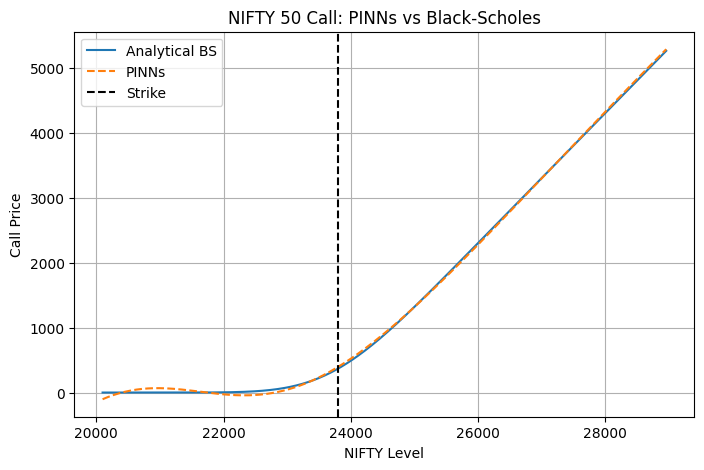

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(S_test, C_true, label="Analytical BS")
plt.plot(S_test, C_pinn, '--', label="PINNs")
plt.axvline(K_scalar, color='black', linestyle='--', label="Strike")
plt.title("NIFTY 50 Call: PINNs vs Black-Scholes")
plt.xlabel("NIFTY Level")
plt.ylabel("Call Price")
plt.legend()
plt.grid()
plt.show()